In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Financial data
import yfinance as yf

# Statistics
from scipy import stats
from statsmodels.tsa.stattools import adfuller

# Machine Learning
from sklearn.preprocessing import MinMaxScaler

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

print("All libraries imported successfully!")

All libraries imported successfully!


# Task 1: Data Preprocessing and Exploratory Data Analysis (EDA)

## Objectives
- Download historical financial data
- Clean and preprocess the data
- Perform exploratory data analysis
- Test for stationarity
- Calculate risk metrics

In [2]:
# Define the assets and date range
tickers = ["TSLA", "BND", "SPY"]

start_date = "2015-01-01"
end_date = "2026-06-30"

In [3]:
# Download historical data
tsla = yf.download("TSLA", start=start_date, end=end_date)
bnd = yf.download("BND", start=start_date, end=end_date)
spy = yf.download("SPY", start=start_date, end=end_date)

print("TSLA Shape:", tsla.shape)
print("BND Shape:", bnd.shape)
print("SPY Shape:", spy.shape)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

TSLA Shape: (2888, 5)
BND Shape: (2888, 5)
SPY Shape: (2888, 5)


In [4]:
print("Tesla")
display(tsla.head())

print("BND")
display(bnd.head())

print("SPY")
display(spy.head())

Tesla


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


BND


Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
Date,,,,,
2015-01-02,59.405411,59.434162,59.240094,59.247283,2218800
2015-01-05,59.577919,59.599481,59.441353,59.470104,5820100
2015-01-06,59.750412,59.930102,59.678537,59.678537,3887600
2015-01-07,59.786373,59.858248,59.692936,59.757622,2433400
2015-01-08,59.692917,59.736041,59.635415,59.736041,1873400


SPY


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,169.687851,170.885580,168.655335,170.472573,121465900
2015-01-05,166.623337,168.812266,166.317716,168.647066,169632600
2015-01-06,165.053879,167.449311,164.260901,166.928919,209151400
2015-01-07,167.110718,167.449386,165.929525,166.375567,125346700
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800


In [5]:
tsla.to_csv("../data/raw/TSLA/tsla.csv")
bnd.to_csv("../data/raw/BND/bnd.csv")
spy.to_csv("../data/raw/SPY/spy.csv")

print("Datasets saved successfully.")

Datasets saved successfully.


In [6]:
# Display basic information about each dataset
print("TSLA")
display(tsla.head())
print(tsla.info())

print("\nBND")
display(bnd.head())
print(bnd.info())

print("\nSPY")
display(spy.head())
print(spy.info())

TSLA


Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
Date,,,,,
2015-01-02,14.620667,14.883333,14.217333,14.858000,71466000
2015-01-05,14.006000,14.433333,13.810667,14.303333,80527500
2015-01-06,14.085333,14.280000,13.614000,14.004000,93928500
2015-01-07,14.063333,14.318667,13.985333,14.223333,44526000
2015-01-08,14.041333,14.253333,14.000667,14.187333,51637500


<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, TSLA)   2888 non-null   float64
 1   (High, TSLA)    2888 non-null   float64
 2   (Low, TSLA)     2888 non-null   float64
 3   (Open, TSLA)    2888 non-null   float64
 4   (Volume, TSLA)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB
None

BND


Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
Date,,,,,
2015-01-02,59.405411,59.434162,59.240094,59.247283,2218800
2015-01-05,59.577919,59.599481,59.441353,59.470104,5820100
2015-01-06,59.750412,59.930102,59.678537,59.678537,3887600
2015-01-07,59.786373,59.858248,59.692936,59.757622,2433400
2015-01-08,59.692917,59.736041,59.635415,59.736041,1873400


<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, BND)   2888 non-null   float64
 1   (High, BND)    2888 non-null   float64
 2   (Low, BND)     2888 non-null   float64
 3   (Open, BND)    2888 non-null   float64
 4   (Volume, BND)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB
None

SPY


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2015-01-02,169.687851,170.885580,168.655335,170.472573,121465900
2015-01-05,166.623337,168.812266,166.317716,168.647066,169632600
2015-01-06,165.053879,167.449311,164.260901,166.928919,209151400
2015-01-07,167.110718,167.449386,165.929525,166.375567,125346700
2015-01-08,170.076096,170.290867,168.498420,168.514931,147217800


<class 'pandas.DataFrame'>
DatetimeIndex: 2888 entries, 2015-01-02 to 2026-06-29
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   (Close, SPY)   2888 non-null   float64
 1   (High, SPY)    2888 non-null   float64
 2   (Low, SPY)     2888 non-null   float64
 3   (Open, SPY)    2888 non-null   float64
 4   (Volume, SPY)  2888 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 135.4 KB
None


In [7]:
# Check dataset dimensions
print("TSLA Shape:", tsla.shape)
print("BND Shape:", bnd.shape)
print("SPY Shape:", spy.shape)

TSLA Shape: (2888, 5)
BND Shape: (2888, 5)
SPY Shape: (2888, 5)


In [8]:
# Summary statistics
display(tsla.describe())
display(bnd.describe())
display(spy.describe())

Price,Close,High,Low,Open,Volume
Ticker,TSLA,TSLA,TSLA,TSLA,TSLA
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,148.773923,151.990563,145.416731,148.797341,1.087922e+08
std,138.895957,141.852818,135.867193,138.977191,7.082549e+07
min,9.578000,10.331333,9.403333,9.488000,1.062000e+07
25%,18.393499,18.665168,18.023666,18.390833,6.548325e+07
50%,133.437668,136.053329,125.831669,131.496330,9.033615e+07
75%,251.925831,257.485008,245.832500,251.680004,1.261204e+08
max,489.880005,498.829987,485.329987,489.880005,9.140820e+08


Price,Close,High,Low,Open,Volume
Ticker,BND,BND,BND,BND,BND
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,66.503053,66.600149,66.404061,66.505297,4.653786e+06
std,4.713606,4.719858,4.705621,4.713243,3.017704e+06
min,58.729256,58.801873,58.692953,58.758301,0.000000e+00
25%,62.478090,62.536715,62.405111,62.472863,2.233700e+06
50%,65.728409,65.852778,65.596767,65.712484,4.280650e+06
75%,70.689154,70.843016,70.549773,70.688886,6.246475e+06
max,74.832893,74.924892,74.799440,74.891445,3.396300e+07


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
count,2888.000000,2888.000000,2888.000000,2888.000000,2.888000e+03
mean,351.505531,353.335694,349.374635,351.441777,8.551049e+07
std,155.443935,156.153561,154.576728,155.414686,4.338553e+07
min,154.161591,155.206987,152.073435,153.723197,2.027000e+07
25%,223.546799,224.825568,222.172440,223.474552,5.836455e+07
50%,312.817917,315.491392,310.494715,314.142277,7.541950e+07
75%,432.806801,434.994720,430.305327,432.604473,9.882245e+07
max,757.618225,758.446109,754.805464,756.201867,5.072443e+08


In [9]:
# Check missing values
print("TSLA Missing Values")
display(tsla.isnull().sum())

print("\nBND Missing Values")
display(bnd.isnull().sum())

print("\nSPY Missing Values")
display(spy.isnull().sum())

TSLA Missing Values


Price   Ticker
Close   TSLA      0
High    TSLA      0
Low     TSLA      0
Open    TSLA      0
Volume  TSLA      0
dtype: int64


BND Missing Values


Price   Ticker
Close   BND       0
High    BND       0
Low     BND       0
Open    BND       0
Volume  BND       0
dtype: int64


SPY Missing Values


Price   Ticker
Close   SPY       0
High    SPY       0
Low     SPY       0
Open    SPY       0
Volume  SPY       0
dtype: int64

In [10]:
# Check duplicate rows
print("TSLA Duplicates:", tsla.duplicated().sum())
print("BND Duplicates:", bnd.duplicated().sum())
print("SPY Duplicates:", spy.duplicated().sum())

TSLA Duplicates: 0
BND Duplicates: 0
SPY Duplicates: 0


In [11]:
# Handle missing values
tsla = tsla.ffill().bfill()
bnd = bnd.ffill().bfill()
spy = spy.ffill().bfill()

In [12]:
# Verify data types
print(tsla.dtypes)
print(bnd.dtypes)
print(spy.dtypes)

Price   Ticker
Close   TSLA      float64
High    TSLA      float64
Low     TSLA      float64
Open    TSLA      float64
Volume  TSLA        int64
dtype: object
Price   Ticker
Close   BND       float64
High    BND       float64
Low     BND       float64
Open    BND       float64
Volume  BND         int64
dtype: object
Price   Ticker
Close   SPY       float64
High    SPY       float64
Low     SPY       float64
Open    SPY       float64
Volume  SPY         int64
dtype: object


In [13]:
print(tsla.index)

DatetimeIndex(['2015-01-02', '2015-01-05', '2015-01-06', '2015-01-07',
               '2015-01-08', '2015-01-09', '2015-01-12', '2015-01-13',
               '2015-01-14', '2015-01-15',
               ...
               '2026-06-15', '2026-06-16', '2026-06-17', '2026-06-18',
               '2026-06-22', '2026-06-23', '2026-06-24', '2026-06-25',
               '2026-06-26', '2026-06-29'],
              dtype='datetime64[s]', name='Date', length=2888, freq=None)


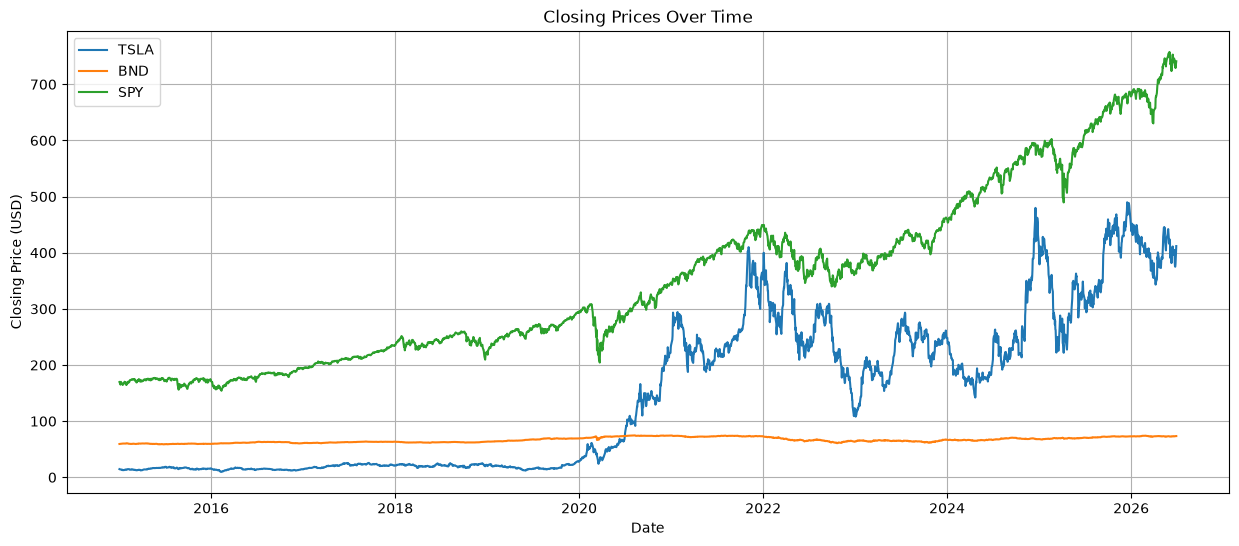

In [14]:
# Plot closing prices for all assets
plt.figure(figsize=(15, 6))

plt.plot(tsla.index, tsla["Close"], label="TSLA")
plt.plot(bnd.index, bnd["Close"], label="BND")
plt.plot(spy.index, spy["Close"], label="SPY")

plt.title("Closing Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

### Closing Price Analysis

- TSLA shows significant long-term growth with higher volatility.
- BND remains relatively stable, reflecting its lower-risk bond profile.
- SPY demonstrates a steady upward trend with moderate fluctuations, representing the broader U.S. stock market.

In [15]:
# Calculate daily percentage returns
tsla["Daily_Return"] = tsla["Close"].pct_change()
bnd["Daily_Return"] = bnd["Close"].pct_change()
spy["Daily_Return"] = spy["Close"].pct_change()

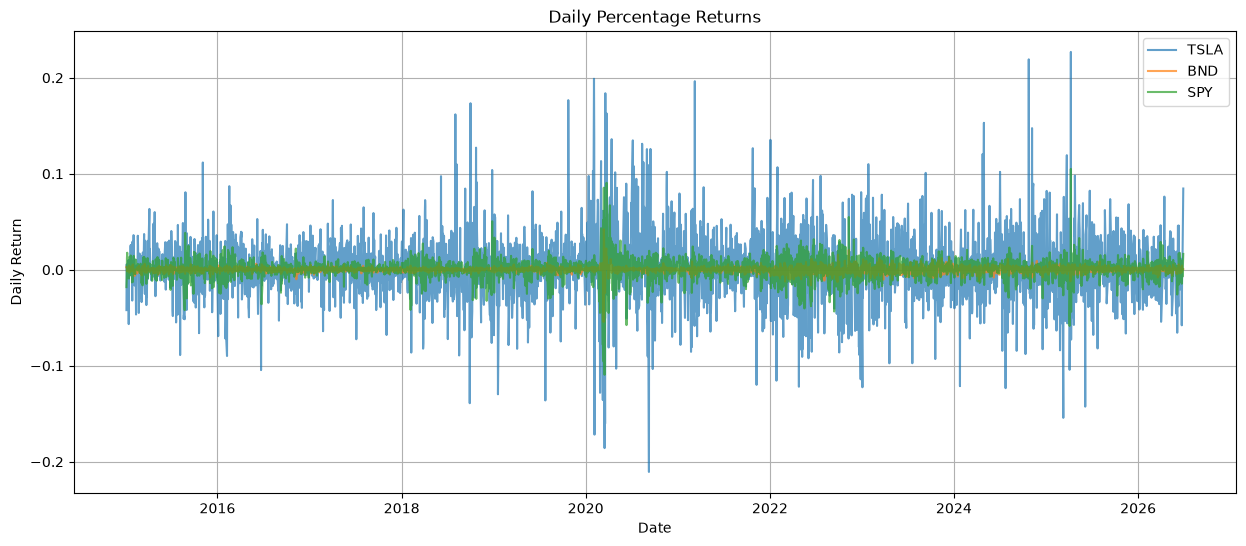

In [16]:
plt.figure(figsize=(15,6))

plt.plot(tsla.index, tsla["Daily_Return"], label="TSLA", alpha=0.7)
plt.plot(bnd.index, bnd["Daily_Return"], label="BND", alpha=0.7)
plt.plot(spy.index, spy["Daily_Return"], label="SPY", alpha=0.7)

plt.title("Daily Percentage Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.legend()
plt.grid(True)

plt.show()

### Daily Returns Analysis

- Tesla (TSLA) exhibits the largest day-to-day fluctuations, indicating higher volatility and investment risk.
- BND has relatively small daily return changes, consistent with its role as a low-risk bond ETF.
- SPY shows moderate fluctuations, reflecting diversified exposure to the overall U.S. stock market.

In [17]:
# Calculate 30-day rolling mean
tsla["Rolling_Mean_30"] = tsla["Close"].rolling(window=30).mean()
bnd["Rolling_Mean_30"] = bnd["Close"].rolling(window=30).mean()
spy["Rolling_Mean_30"] = spy["Close"].rolling(window=30).mean()

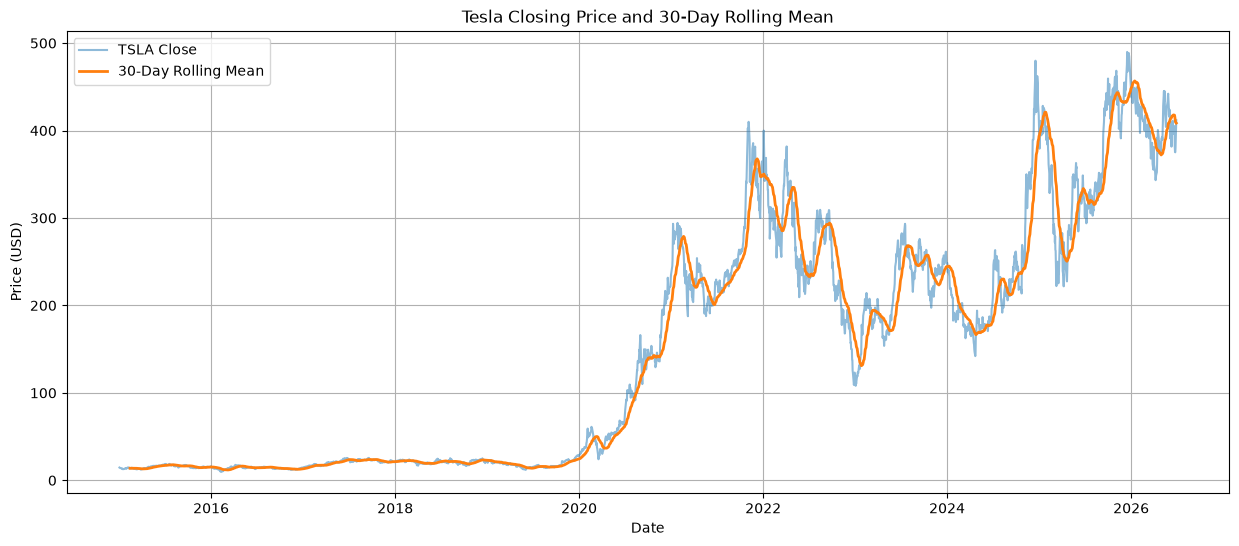

In [18]:
plt.figure(figsize=(15, 6))

plt.plot(tsla.index, tsla["Close"], label="TSLA Close", alpha=0.5)
plt.plot(tsla.index, tsla["Rolling_Mean_30"], label="30-Day Rolling Mean", linewidth=2)

plt.title("Tesla Closing Price and 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)

plt.show()

### Rolling Mean Analysis

The 30-day rolling mean smooths short-term price fluctuations and highlights the underlying trend. For Tesla, the rolling mean follows the long-term upward movement while reducing daily market noise, making overall trends easier to observe.

In [19]:
# Calculate rolling volatility
tsla["Rolling_STD_30"] = tsla["Daily_Return"].rolling(window=30).std()
bnd["Rolling_STD_30"] = bnd["Daily_Return"].rolling(window=30).std()
spy["Rolling_STD_30"] = spy["Daily_Return"].rolling(window=30).std()

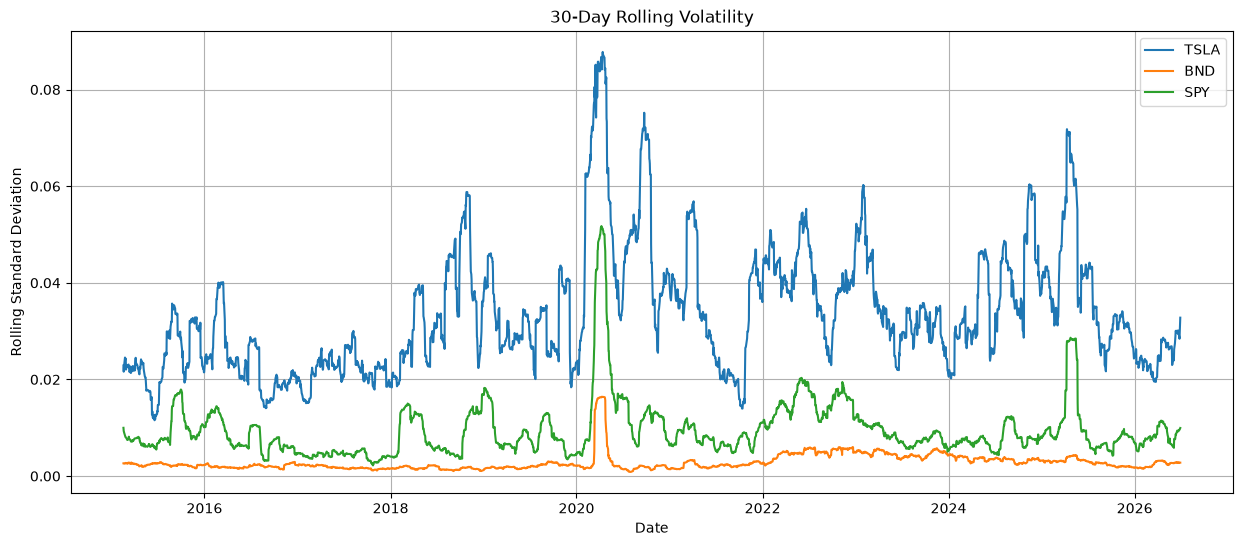

In [20]:
plt.figure(figsize=(15, 6))

plt.plot(tsla.index, tsla["Rolling_STD_30"], label="TSLA")
plt.plot(bnd.index, bnd["Rolling_STD_30"], label="BND")
plt.plot(spy.index, spy["Rolling_STD_30"], label="SPY")

plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Standard Deviation")
plt.legend()
plt.grid(True)

plt.show()

### Rolling Volatility Analysis

- TSLA exhibits the highest rolling volatility, indicating greater investment risk and larger short-term price fluctuations.
- BND maintains consistently low volatility, demonstrating its stability as a bond ETF.
- SPY shows moderate volatility, reflecting diversified exposure to the broader equity market.

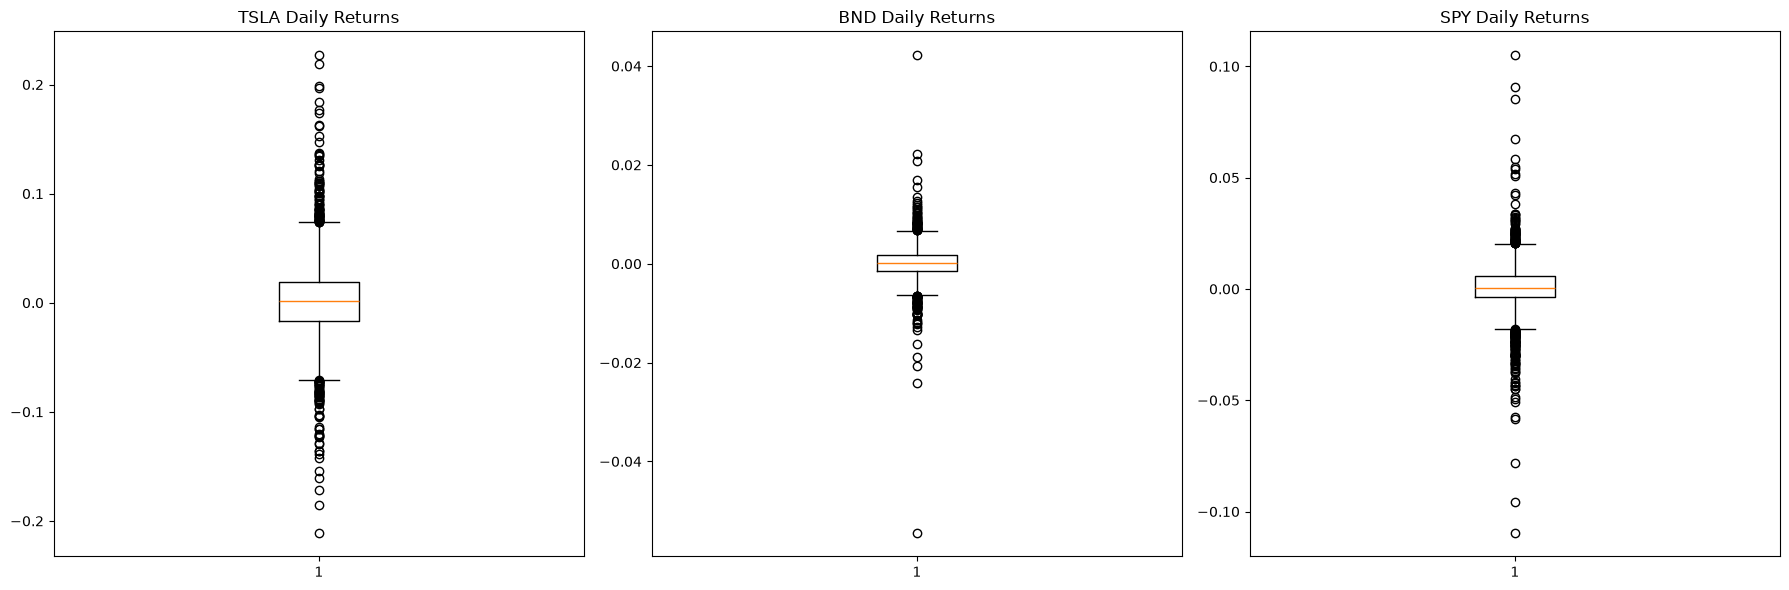

In [21]:
# Box plots for daily returns
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].boxplot(tsla["Daily_Return"].dropna())
axes[0].set_title("TSLA Daily Returns")

axes[1].boxplot(bnd["Daily_Return"].dropna())
axes[1].set_title("BND Daily Returns")

axes[2].boxplot(spy["Daily_Return"].dropna())
axes[2].set_title("SPY Daily Returns")

plt.tight_layout()
plt.show()

### Outlier Detection

The box plots reveal the presence of outliers in all three assets. Tesla (TSLA) contains the most extreme outliers, indicating large price swings and higher market risk. BND has relatively few outliers, reflecting its stability, while SPY exhibits moderate outliers consistent with broad market movements.

In [22]:
print("TSLA Highest Daily Return")
display(tsla.nlargest(5, "Daily_Return")[["Close", "Daily_Return"]])

print("\nTSLA Lowest Daily Return")
display(tsla.nsmallest(5, "Daily_Return")[["Close", "Daily_Return"]])

print("\nBND Highest Daily Return")
display(bnd.nlargest(5, "Daily_Return")[["Close", "Daily_Return"]])

print("\nBND Lowest Daily Return")
display(bnd.nsmallest(5, "Daily_Return")[["Close", "Daily_Return"]])

print("\nSPY Highest Daily Return")
display(spy.nlargest(5, "Daily_Return")[["Close", "Daily_Return"]])

print("\nSPY Lowest Daily Return")
display(spy.nsmallest(5, "Daily_Return")[["Close", "Daily_Return"]])

TSLA Highest Daily Return


Price,Close,Daily_Return
Ticker,TSLA,
Date,,
2025-04-09,272.200012,0.226900
2024-10-24,260.480011,0.219190
2020-02-03,52.000000,0.198949
2021-03-09,224.526672,0.196412
2020-03-19,28.509333,0.183877



TSLA Lowest Daily Return


Price,Close,Daily_Return
Ticker,TSLA,
Date,,
2020-09-08,110.070000,-0.210628
2020-03-16,29.671333,-0.185778
2020-02-05,48.980000,-0.171758
2020-03-18,24.081333,-0.160344
2025-03-10,222.149994,-0.154262



BND Highest Daily Return


...

Price,Close,Daily_Return
Ticker,BND,
Date,,
2020-03-12,66.528366,-0.054385
2020-03-18,66.959000,-0.024140
2020-03-17,68.615356,-0.020686
2020-03-11,70.354568,-0.018940
2022-06-13,64.188911,-0.016152



SPY Highest Daily Return


Price,Close,Daily_Return
Ticker,SPY,
Date,,
2025-04-09,541.008423,0.105019
2020-03-24,222.939194,0.090603
2020-03-13,245.490448,0.085487
2020-04-06,242.844635,0.067166
2020-03-26,239.488876,0.058390



SPY Lowest Daily Return


Price,Close,Daily_Return
Ticker,SPY,
Date,,
2020-03-16,218.627945,-0.109424
2020-03-12,226.157043,-0.095677
2020-03-09,249.965973,-0.078094
2025-04-04,498.269684,-0.058543
2020-06-11,275.623077,-0.057649


### High and Low Return Analysis

Tesla experienced the largest positive and negative daily returns among the three assets, confirming its high volatility. BND showed comparatively small return fluctuations, while SPY demonstrated moderate changes that reflect general market conditions.

In [23]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, title=""):
    result = adfuller(series.dropna())

    print("=" * 60)
    print(title)
    print("=" * 60)
    print(f"ADF Statistic : {result[0]:.4f}")
    print(f"P-value       : {result[1]:.4f}")
    print(f"Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")

    if result[1] < 0.05:
        print("\nResult: The series is stationary.")
    else:
        print("\nResult: The series is NOT stationary.")

In [24]:
adf_test(tsla["Close"], "TSLA Closing Price")
adf_test(tsla["Daily_Return"], "TSLA Daily Returns")

adf_test(bnd["Close"], "BND Closing Price")
adf_test(bnd["Daily_Return"], "BND Daily Returns")

adf_test(spy["Close"], "SPY Closing Price")
adf_test(spy["Daily_Return"], "SPY Daily Returns")

TSLA Closing Price
ADF Statistic : -1.0696
P-value       : 0.7270
Critical Values:
   1%: -3.4326
   5%: -2.8626
   10%: -2.5673

Result: The series is NOT stationary.
TSLA Daily Returns
ADF Statistic : -53.9719
P-value       : 0.0000
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Result: The series is stationary.
BND Closing Price
ADF Statistic : -1.0827
P-value       : 0.7219
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Result: The series is NOT stationary.
BND Daily Returns
ADF Statistic : -15.2161
P-value       : 0.0000
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Result: The series is stationary.
SPY Closing Price
ADF Statistic : 1.3089
P-value       : 0.9967
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Result: The series is NOT stationary.
SPY Daily Returns
ADF Statistic : -17.5722
P-value       : 0.0000
Critical Values:
   1%: -3.4326
   5%: -2.8625
   10%: -2.5673

Result: The series is stationary.


### Stationarity Analysis

The ADF test indicates that the closing price series is generally non-stationary, while the daily return series is stationary. This suggests that differencing is required before fitting ARIMA models on price data, whereas daily returns already satisfy the stationarity assumption.

In [25]:
confidence_level = 0.05

print("Value at Risk (95% Confidence)")

print("TSLA:", tsla["Daily_Return"].quantile(confidence_level))
print("BND :", bnd["Daily_Return"].quantile(confidence_level))
print("SPY :", spy["Daily_Return"].quantile(confidence_level))

Value at Risk (95% Confidence)
TSLA: -0.05166375515284559
BND : -0.004756522842716704
SPY : -0.01665018550774573


### Value at Risk (VaR)

The historical Value at Risk estimates the maximum expected daily loss at the 95% confidence level. Tesla has the largest downside risk, while BND has the lowest expected daily loss.

In [26]:
risk_free_rate = 0.02

def sharpe_ratio(returns):
    excess_return = returns.mean() * 252 - risk_free_rate
    volatility = returns.std() * np.sqrt(252)
    return excess_return / volatility

print("Sharpe Ratios")

print("TSLA:", sharpe_ratio(tsla["Daily_Return"].dropna()))
print("BND :", sharpe_ratio(bnd["Daily_Return"].dropna()))
print("SPY :", sharpe_ratio(spy["Daily_Return"].dropna()))

Sharpe Ratios
TSLA: 0.7594581853138578
BND : -0.0008094994798022802
SPY : 0.7041778341214397


### Sharpe Ratio Analysis

The Sharpe Ratio measures risk-adjusted performance. A higher Sharpe Ratio indicates better returns relative to risk. Comparing the three assets helps identify which offers the best balance between return and volatility.

In [27]:
tsla.to_csv("../data/processed/tsla_processed.csv")
bnd.to_csv("../data/processed/bnd_processed.csv")
spy.to_csv("../data/processed/spy_processed.csv")

print("Processed datasets saved successfully.")

Processed datasets saved successfully.


# Task 1 Summary

## Data Extraction
Historical financial data for TSLA, BND, and SPY was successfully downloaded using the yfinance library for the period from January 1, 2015 to June 30, 2026.

## Data Quality
The datasets were inspected for missing values, duplicate records, and incorrect data types. Missing values were handled using forward-fill and backward-fill where necessary, and the datasets were confirmed to be suitable for analysis.

## Exploratory Data Analysis
The closing price analysis showed strong long-term growth and high volatility for Tesla, stable performance for BND, and moderate growth for SPY. Daily return analysis and rolling statistics highlighted differences in risk and short-term fluctuations across the assets. Box plots identified several outliers, particularly for Tesla.

## Stationarity
The Augmented Dickey-Fuller (ADF) test indicated that the closing price series is non-stationary, while the daily return series is stationary. This confirms that differencing will be necessary when fitting ARIMA models to price data in Task 2.

## Risk Metrics
Historical Value at Risk (VaR) and Sharpe Ratio were calculated to assess downside risk and risk-adjusted performance. Tesla exhibited the highest potential returns alongside the greatest risk, BND provided the lowest risk profile, and SPY offered a balanced risk-return profile suitable for diversified portfolio construction.

## Conclusion
The datasets have been successfully extracted, cleaned, analyzed, and prepared for forecasting. The insights gained from the exploratory analysis will guide model selection and portfolio optimization in the subsequent tasks.